In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv("train_data_preprocessed.csv")

In [3]:
target_cols = ["IC50, mM", "CC50, mM", "SI"]
X_reg = df.drop(columns=target_cols + ["log10_IC50", "log10_CC50", "log10_SI"])
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)
X_train, X_test, idx_train, idx_test = train_test_split(X_reg_scaled,df.index,test_size=0.2,random_state=42)
y = df["log10_CC50"]
y_train = y.loc[idx_train]
y_test = y.loc[idx_test]

In [4]:
#модели
models = {"LinearRegression": LinearRegression(),"Ridge": Ridge(alpha=1.0),"Lasso": Lasso(alpha=0.001, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=300,max_depth=None,random_state=42,n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=3,random_state=42),}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append((name, rmse, r2))

results_df = pd.DataFrame(results, columns=["model", "RMSE", "R2"])
print(results_df.sort_values("RMSE"))

              model      RMSE        R2
3      RandomForest  0.507690  0.423908
4  GradientBoosting  0.528119  0.376613
2             Lasso  0.537511  0.354242
1             Ridge  0.558274  0.303391
0  LinearRegression  0.615972  0.151961


In [5]:
#Randomforest
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42,n_jobs=-1)

param_grid = {"n_estimators": [200, 300, 500],"max_depth": [None, 10, 20],"min_samples_leaf": [1, 2, 4]}
grid_rf = GridSearchCV(rf,param_grid,scoring="neg_root_mean_squared_error",n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Лучшие параметры:", grid_rf.best_params_)
print("Лучший RMSE (CV):", -grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

y_pred_test = best_rf.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("RMSE на тесте (RandomForest):", rmse_test)
print("R2 на тесте (RandomForest):", r2_test)

Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 500}
Лучший RMSE (CV): 0.5562514867372912
RMSE на тесте (RandomForest): 0.5064600434310125
R2 на тесте (RandomForest): 0.4266967636590605


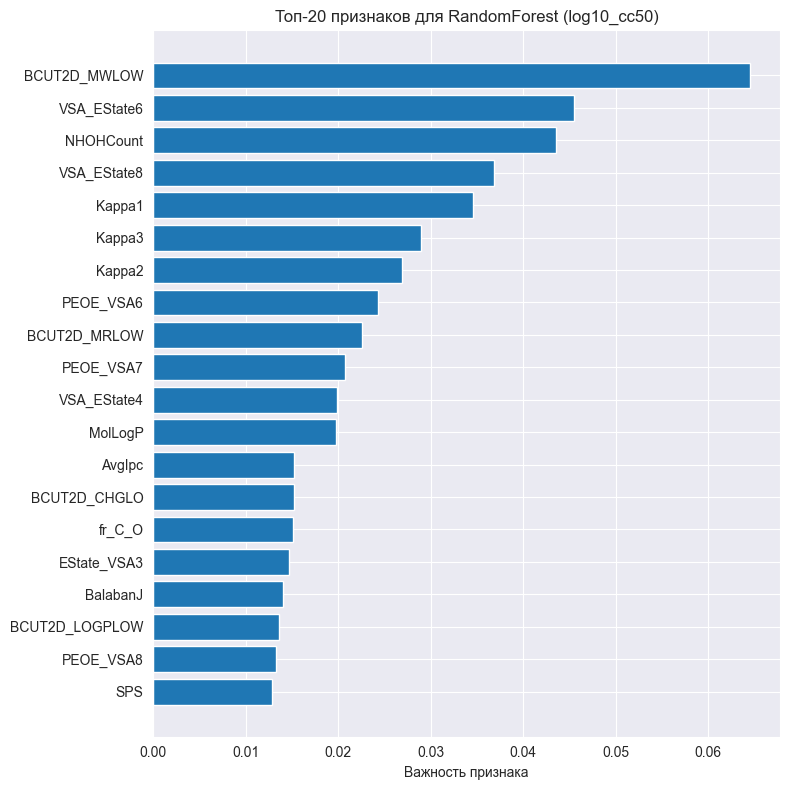

In [6]:
import matplotlib.pyplot as plt

feature_names = X_reg.columns
importances = best_rf.feature_importances_

idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 8))
plt.barh(range(len(idx)), importances[idx][::-1])
plt.yticks(range(len(idx)), feature_names[idx][::-1])
plt.xlabel("Важность признака")
plt.title("Топ-20 признаков для RandomForest (log10_сс50)")
plt.tight_layout()
plt.show()

In [7]:
#бустинг
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score

gb = GradientBoostingRegressor(random_state=42)

param_grid_gb = {"n_estimators": [200, 300, 500],"learning_rate": [0.03, 0.05, 0.1],"max_depth": [2, 3, 4]}

grid_gb = GridSearchCV(gb,param_grid_gb,scoring="neg_root_mean_squared_error",cv=3,n_jobs=-1)

grid_gb.fit(X_train, y_train)

print("Лучшие параметры GB:", grid_gb.best_params_)
print("Лучший RMSE (CV) GB:", -grid_gb.best_score_)

best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
rmse_gb = root_mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("RMSE на тесте (GB):", rmse_gb)
print("R2 на тесте (GB):", r2_gb)

Лучшие параметры GB: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300}
Лучший RMSE (CV) GB: 0.553134162712543
RMSE на тесте (GB): 0.5139921378220902
R2 на тесте (GB): 0.4095175836715308


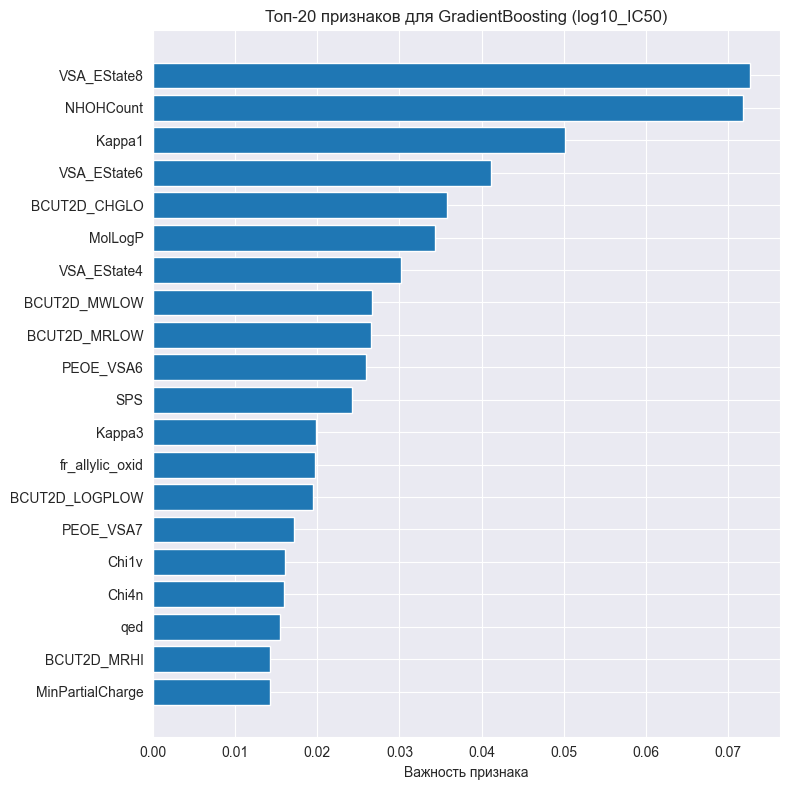

In [8]:
eature_names = X_reg.columns
importances_gb = best_gb.feature_importances_
idx = np.argsort(importances_gb)[::-1][:20]

plt.figure(figsize=(8, 8))
plt.barh(range(len(idx)), importances_gb[idx][::-1])
plt.yticks(range(len(idx)), feature_names[idx][::-1])
plt.xlabel("Важность признака")
plt.title("Топ-20 признаков для GradientBoosting (log10_IC50)")
plt.tight_layout()
plt.show()

В этом случае Случайный лес показал лучшее качество, по сравнению с бустингом, при этом они оба обошли конкурентов.

Тут был использован такой же набор признаков и те же самые модели(линейные и ансамблевые). Линейные снова показали качество хуже, чем ансамбли. Анализ важности признаков в лучшем лесу показывает, что тут в первую очередь влияют масса, размер и площадь поверхности молекулы, а так же эл-поверхностные показатели. Это согласуется с тем, что токсичность сильнее связана с общими физико-химическими св-вами, чем с отдельными фрагментами.